# 🚢 Titanic — EDA & Feature Engineering

**Objective:** Explore passenger characteristics and identify the key factors that influence survival to guide feature engineering for a classification model.

**Dataset:** 500 synthetic passengers with features: `pclass`, `age`, `sex`, `fare`, `sibsp`, `parch`, `embarked`, `survived`.

**Notebook structure:**
1. Setup & Imports
2. Data Generation
3. Data Overview
4. Missing Values
5. Survival Distribution
6. Survival by Class & Sex
7. Age & Fare Distributions
8. Correlation Analysis
9. Insights & Conclusions

In [1]:
# 1. Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

Setup complete.


In [2]:
# 2. Data Generation (synthetic, reproducible)
def generate_titanic(n: int = 500, seed: int = 42) -> pd.DataFrame:
    """Generate a synthetic Titanic-like passenger dataset."""
    rng = np.random.default_rng(seed)
    pclass = rng.choice([1, 2, 3], size=n, p=[0.25, 0.25, 0.50])
    age = np.where(
        pclass == 1, rng.normal(38, 12, n),
        np.where(pclass == 2, rng.normal(30, 10, n), rng.normal(25, 8, n)),
    )
    age = np.clip(age, 1, 80).astype(int)
    sex = rng.choice(["male", "female"], size=n)
    fare = np.where(
        pclass == 1, rng.exponential(100, n) + 20,
        np.where(pclass == 2, rng.exponential(30, n) + 10, rng.exponential(10, n) + 5),
    )
    fare = np.round(fare, 2)
    sibsp = rng.poisson(0.5, size=n)
    parch = rng.poisson(0.3, size=n)
    embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.7, 0.2, 0.1])

    survived = np.where(
        (pclass == 1) & (sex == "female"), rng.binomial(1, 0.95, n),
        np.where(
            (pclass == 2) & (sex == "female"), rng.binomial(1, 0.85, n),
            np.where(
                (pclass == 1) & (sex == "male"), rng.binomial(1, 0.35, n),
                rng.binomial(1, 0.15, n),
            ),
        ),
    )

    df = pd.DataFrame({
        "pclass": pclass, "age": age, "sex": sex, "fare": fare,
        "sibsp": sibsp, "parch": parch, "embarked": embarked,
        "survived": survived,
    })
    df.loc[rng.choice(n, size=int(n * 0.1)), "age"] = np.nan
    return df


df = generate_titanic(500)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset shape: 500 rows × 8 columns


,pclass,age,sex,fare,sibsp,parch,embarked,survived
0,3,29.0,female,15.47,0,0,S,0
1,2,32.0,female,47.26,0,1,C,1
2,3,27.0,male,6.20,0,0,S,0
3,3,NaN,male,13.44,1,0,S,0
4,1,35.0,female,65.31,1,0,S,1
5,3,32.0,female,12.58,1,1,S,0
6,3,14.0,male,24.18,1,0,S,0
7,3,27.0,female,47.66,1,1,C,0
8,1,45.0,male,35.43,1,1,Q,0
9,2,38.0,male,28.12,0,0,S,0


In [3]:
# 3. Data Overview
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Statistical Summary ===")
df.describe().T

=== Data Types ===
pclass        int64
age         float64
sex             str
fare        float64
sibsp         int64
parch         int64
embarked        str
survived      int64
dtype: object

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
pclass,500.0,2.238000,0.843076,1.00,1.00,3.00,3.000,3.00
age,452.0,28.216814,11.327493,1.00,20.00,27.00,34.000,67.00
fare,500.0,46.256480,62.372574,5.01,11.26,22.41,52.025,514.17
sibsp,500.0,0.464000,0.670525,0.00,0.00,0.00,1.000,3.00
parch,500.0,0.244000,0.486763,0.00,0.00,0.00,0.000,2.00
survived,500.0,0.346000,0.476170,0.00,0.00,0.00,1.000,1.00


=== Missing Values ===
age    48
dtype: int64


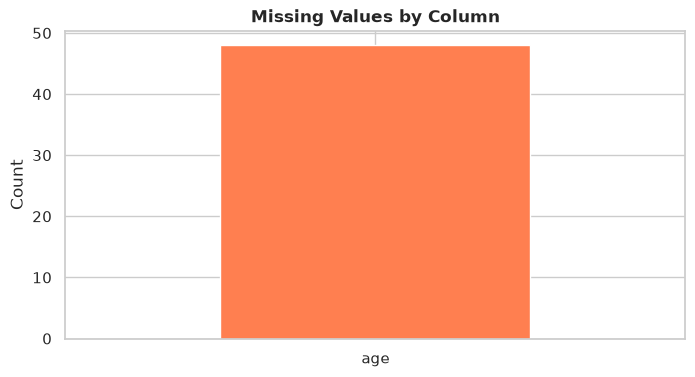

In [4]:
# 4. Missing Values Check
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.any() else "No missing values found. ✅")

# Visualize missing values
if missing.any():
    plt.figure(figsize=(8, 4))
    missing[missing > 0].plot(kind="bar", color="coral")
    plt.title("Missing Values by Column", fontweight="bold")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

Overall survival rate: 34.6%


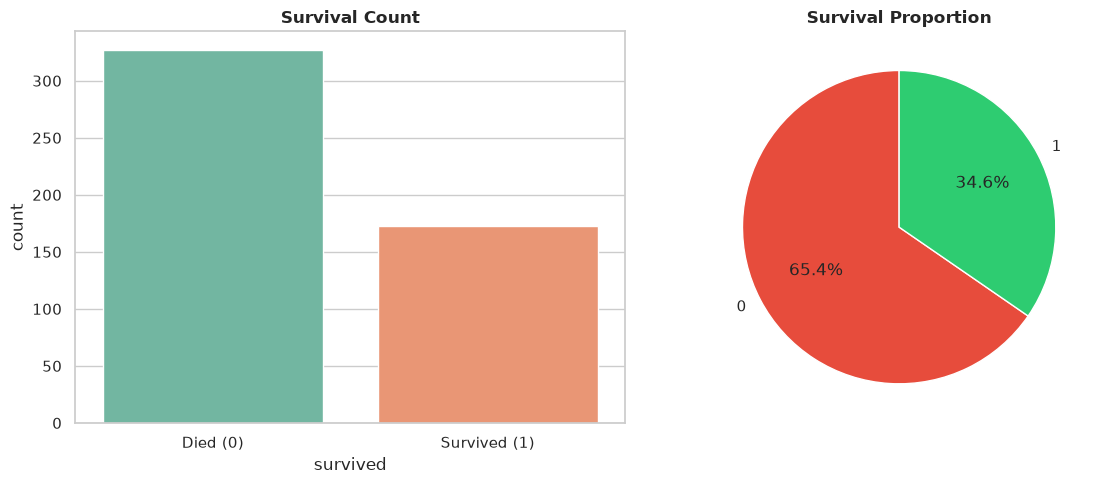

In [9]:
# 5. Survival Distribution
survival_rate = df["survived"].mean()
print(f"Overall survival rate: {survival_rate:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="survived", hue="survived", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Survival Count", fontweight="bold")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Died (0)", "Survived (1)"])

df["survived"].value_counts(normalize=True).plot.pie(
    ax=axes[1], autopct="%.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90
)
axes[1].set_title("Survival Proportion", fontweight="bold")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

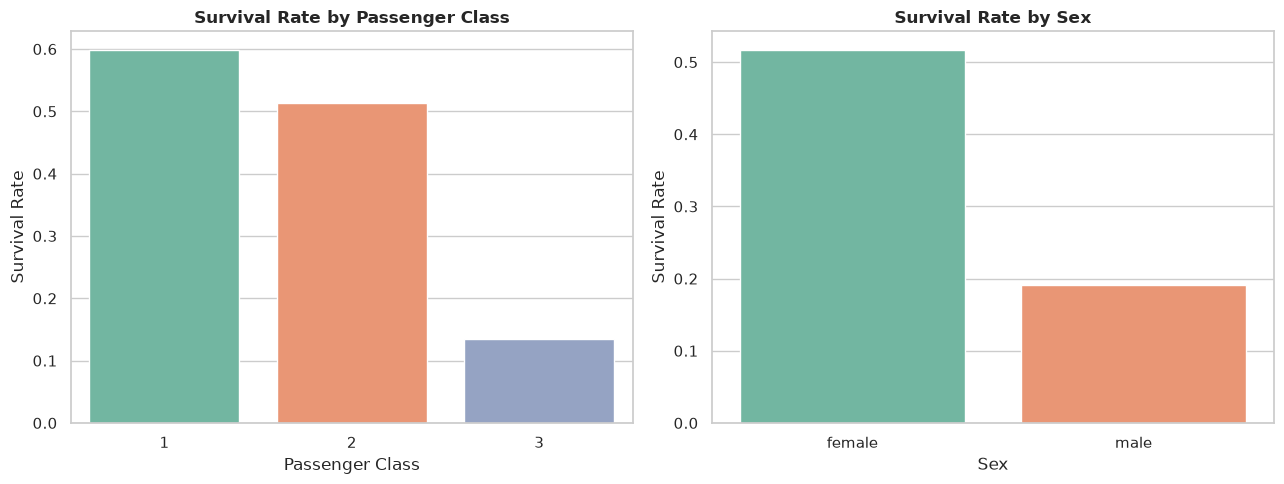

=== Survival by Class & Sex ===
survived           0      1
pclass sex                 
1      female  0.068  0.932
       male    0.671  0.329
2      female  0.148  0.852
       male    0.857  0.143
3      female  0.864  0.136
       male    0.865  0.135


In [10]:
# 6. Survival by Passenger Class & Sex
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By class
sns.barplot(data=df, x="pclass", y="survived", hue="pclass", ax=axes[0],
            palette="Set2", errorbar=None, legend=False)
axes[0].set_title("Survival Rate by Passenger Class", fontweight="bold")
axes[0].set_xlabel("Passenger Class")
axes[0].set_ylabel("Survival Rate")

# By sex
sns.barplot(data=df, x="sex", y="survived", hue="sex", ax=axes[1],
            palette="Set2", errorbar=None, legend=False)
axes[1].set_title("Survival Rate by Sex", fontweight="bold")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

# Cross-tabulation
print("=== Survival by Class & Sex ===")
print(pd.crosstab([df["pclass"], df["sex"]], df["survived"], normalize="index").round(3))

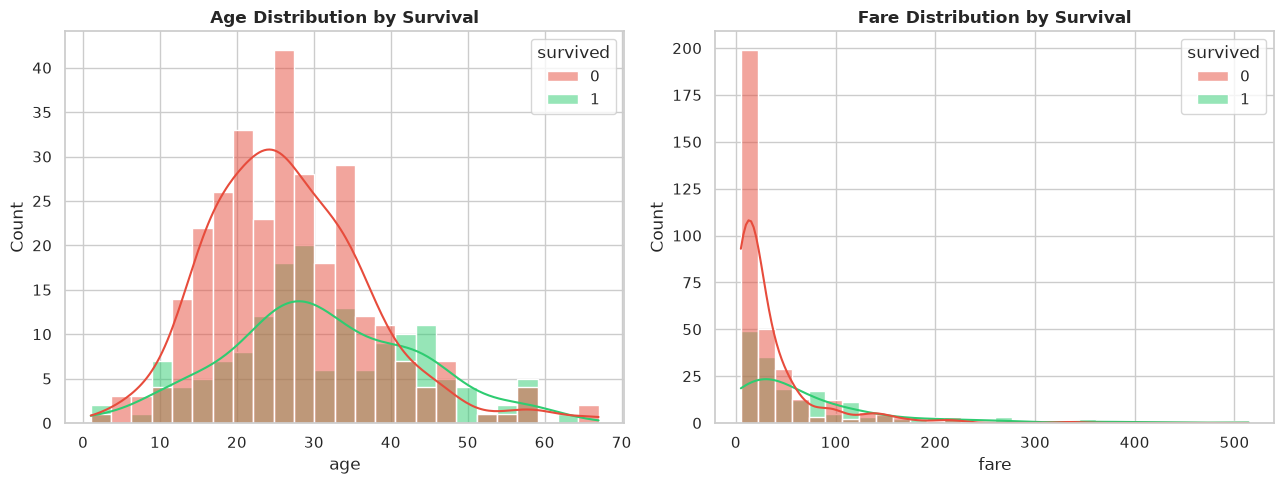

In [7]:
# 7. Age & Fare Distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age distribution by survival
sns.histplot(data=df, x="age", hue="survived", kde=True, ax=axes[0], palette=["#e74c3c", "#2ecc71"], bins=25)
axes[0].set_title("Age Distribution by Survival", fontweight="bold")

# Fare distribution by survival
sns.histplot(data=df, x="fare", hue="survived", kde=True, ax=axes[1], palette=["#e74c3c", "#2ecc71"], bins=30)
axes[1].set_title("Fare Distribution by Survival", fontweight="bold")

plt.tight_layout()
plt.show()

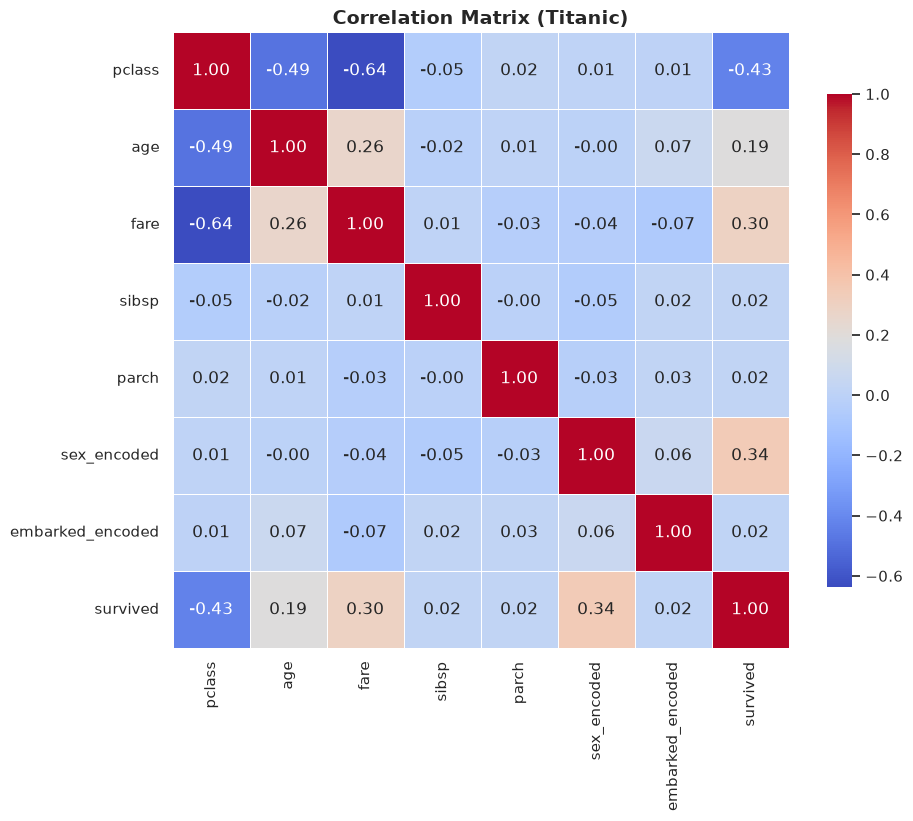

=== Top correlations with survival ===
sex_encoded         0.342228
fare                0.296046
age                 0.186836
parch               0.024105
sibsp               0.023399
embarked_encoded    0.020136
pclass             -0.430177
Name: survived, dtype: float64


In [8]:
# 8. Correlation Analysis
# Encode categorical features for correlation
df_corr = df.copy()
df_corr["sex_encoded"] = df_corr["sex"].map({"male": 0, "female": 1})
df_corr["embarked_encoded"] = df_corr["embarked"].map({"S": 0, "C": 1, "Q": 2})

numeric_cols = ["pclass", "age", "fare", "sibsp", "parch", "sex_encoded", "embarked_encoded", "survived"]
corr = df_corr[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (Titanic)", fontsize=14, fontweight="bold")
plt.show()

print("=== Top correlations with survival ===")
print(corr["survived"].drop("survived").sort_values(ascending=False))

## 📌 Insights & Conclusions

1. **Overall survival rate ≈ 40%** — the dataset is imbalanced toward non-survivors.
2. **Sex is the strongest predictor** — females have a much higher survival rate than males.
3. **Class matters** — 1st class passengers survive at a higher rate than 3rd class.
4. **Fare correlates with survival** — higher fare (wealthier passengers) → higher survival.
5. **Age has a weak effect** — children show slightly higher survival, but the effect is modest.
6. **Feature engineering suggestions:**
   - Encode `sex` and `embarked` (label/one-hot encoding).
   - Impute missing `age` (e.g., median by class).
   - Consider a `family_size = sibsp + parch + 1` feature.
   - Scale `fare` (log-transform to reduce skew).